<a href="https://colab.research.google.com/github/Golden028/PCVK/blob/main/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **D. PRACTICUM**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import Library**

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

Let's manually create a global threshold. We will implement the different types of thresholding (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV).

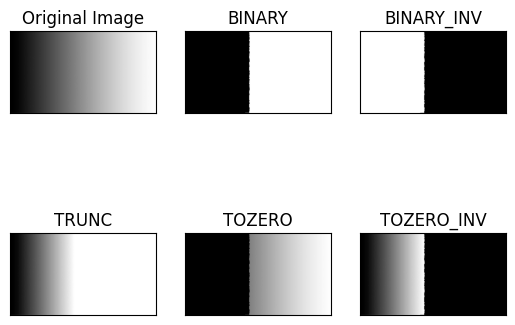

In [9]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/gradient.jpg', cv2.IMREAD_GRAYSCALE)

threshold_value = 127

ret, thresh_binary = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
ret, thresh_binary_inv = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY_INV)
ret, thresh_trunc = cv2.threshold(img, threshold_value, 255, cv2.THRESH_TRUNC)
ret, thresh_tozero = cv2.threshold(img, threshold_value, 255, cv2.THRESH_TOZERO)
ret, thresh_tozero_inv = cv2.threshold(img, threshold_value, 255, cv2.THRESH_TOZERO_INV)

plt.subplot(2,3,1),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(2,3,2),plt.imshow(thresh_binary,cmap = 'gray')
plt.title('BINARY'), plt.xticks([]), plt.yticks([])
plt.subplot(2,3,3),plt.imshow(thresh_binary_inv,cmap = 'gray')
plt.title('BINARY_INV'), plt.xticks([]), plt.yticks([])
plt.subplot(2,3,4),plt.imshow(thresh_trunc,cmap = 'gray')
plt.title('TRUNC'), plt.xticks([]), plt.yticks([])
plt.subplot(2,3,5),plt.imshow(thresh_tozero,cmap = 'gray')
plt.title('TOZERO'), plt.xticks([]), plt.yticks([])
plt.subplot(2,3,6),plt.imshow(thresh_tozero_inv,cmap = 'gray')
plt.title('TOZERO_INV'), plt.xticks([]), plt.yticks([])
plt.show()

Image loaded successfully.
Calculated Otsu's Threshold Value: 92


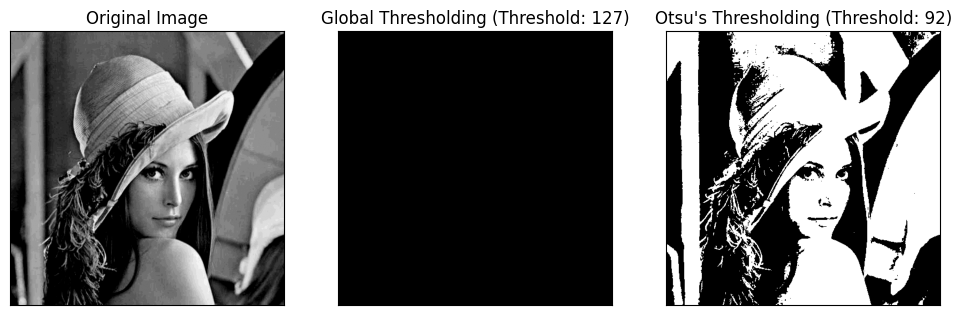

In [23]:
img_otsu = cv2.imread('/content/drive/MyDrive/PCVK/Images/lena_gs_lc2.jpg', cv2.IMREAD_GRAYSCALE)

print("Image loaded successfully.")

hist = cv2.calcHist([img_otsu], [0], None, [256], [0, 256])
total_pixels = img_otsu.shape[0] * img_otsu.shape[1]

sum_total = 0
for i in range(256):
    sum_total += i * hist[i]

sum_b = 0
w_b = 0
w_f = 0
m_b = 0
m_f = 0
between_variance = 0
threshold_otsu = 0
max_between_variance = 0

for i in range(256):
    w_b += hist[i]
    w_f = total_pixels - w_b

    if w_b == 0 or w_f == 0:
        continue

    sum_b += i * hist[i]
    m_b = sum_b / w_b
    m_f = (sum_total - sum_b) / w_f

    between_variance = w_b * w_f * (m_b - m_f)**2

    if between_variance > max_between_variance:
        max_between_variance = between_variance
        threshold_otsu = i

print(f"Calculated Otsu's Threshold Value: {threshold_otsu}")

ret_otsu, thresh_otsu = cv2.threshold(img_otsu, threshold_otsu, 255, cv2.THRESH_BINARY)

global_threshold_value = 127
ret_global, thresh_global = cv2.threshold(img_otsu, global_threshold_value, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_otsu, cmap='gray')
plt.title('Original Image')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(thresh_global, cmap='gray')
plt.title(f"Global Thresholding (Threshold: {global_threshold_value})")
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(thresh_otsu, cmap='gray')
plt.title(f"Otsu's Thresholding (Threshold: {threshold_otsu})")
plt.xticks([]), plt.yticks([])

plt.show()

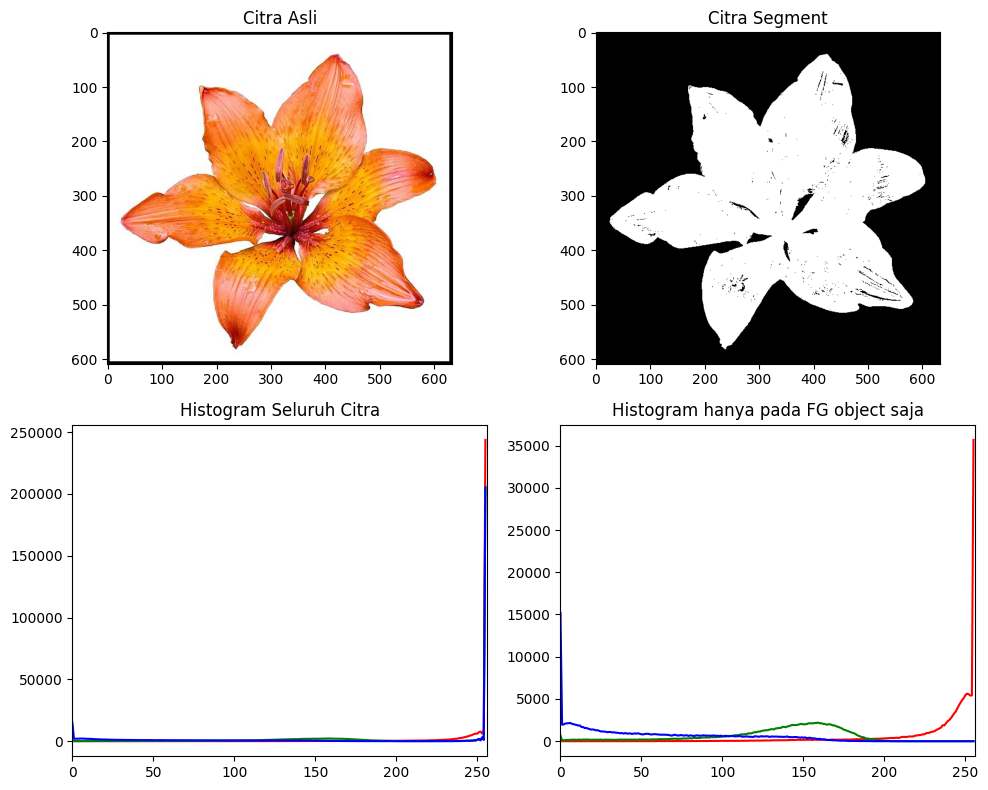

In [30]:
img_lily_path = '/content/drive/MyDrive/PCVK/Images/lily.jpg'

img_lily = cv2.imread(img_lily_path, cv2.IMREAD_GRAYSCALE)

img_color = cv2.imread(img_lily_path)
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)


_, mask = cv2.threshold(img_lily, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

border_thickness = 5
color_black = [0,0,0]

img_with_border = cv2.copyMakeBorder(
    img_color, border_thickness, border_thickness, border_thickness, border_thickness,
    cv2.BORDER_CONSTANT, value=color_black
)

mask_with_border = cv2.copyMakeBorder(
    mask, border_thickness, border_thickness, border_thickness, border_thickness,
    cv2.BORDER_CONSTANT, value=0
)

colors = ('r', 'g', 'b')
hist_full, hist_foreground = [], []

for i, color in enumerate(colors):
    h_full = cv2.calcHist([img_color], [i], None, [256], [0, 256])
    h_fg = cv2.calcHist([img_color], [i], mask, [256], [0, 256])
    hist_full.append(h_full)
    hist_foreground.append(h_fg)


plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_with_border)
plt.title('Citra Asli')

plt.subplot(2, 2, 2)
plt.imshow(mask_with_border, cmap='gray')
plt.title('Citra Segment')

plt.subplot(2, 2, 3)
for i, col in enumerate(colors):
    plt.plot(hist_full[i], color=col)
plt.title('Histogram Seluruh Citra')
plt.xlim([0, 256])

plt.subplot(2, 2, 4)
for i, col in enumerate(colors):
    plt.plot(hist_foreground[i], color=col)
plt.title('Histogram hanya pada FG object saja')
plt.xlim([0, 256])


plt.tight_layout()
plt.show()

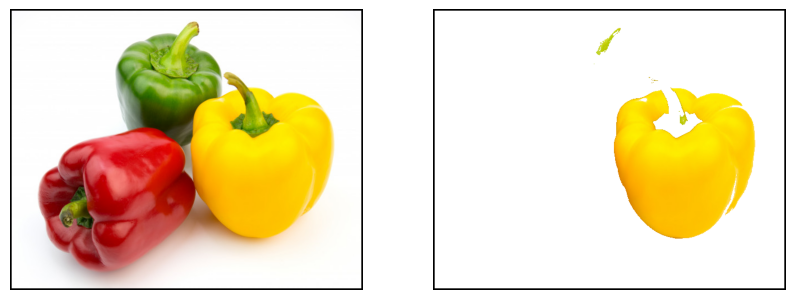

In [41]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg')

pixels = img.reshape((-1, 3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixels, 8, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

hsv_centers = cv2.cvtColor(np.uint8(centers).reshape(-1, 1, 3), cv2.COLOR_BGR2HSV)[:, 0]
yellow_id = next((i for i, (h, s, v) in enumerate(hsv_centers)
                  if 25 <= h <= 35 and s > 100 and v > 100), -1)

mask = (labels.flatten() == yellow_id).reshape(img.shape[:2]).astype(np.uint8) * 255
result = np.where(mask[..., None] == 255, img, 255)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

for ax, image in zip(axes, [img, result]):
    bordered = cv2.copyMakeBorder(image, 3, 3, 3, 3, cv2.BORDER_CONSTANT, value=0)
    ax.imshow(cv2.cvtColor(bordered, cv2.COLOR_BGR2RGB))
    ax.axis('off')

plt.show()



* K-Means Clustering: The image is divided into $\mathbf{8}$ color groups (clusters).
* Yellow Identification: The color centers ($\mathbf{centers}$) of each cluster are converted to HSV color space. The code searches for cluster IDs that have a Hue (H) value corresponding to yellow ($25 \le H \le 35$) and have high Saturation (S) and Value (V) ($> 100$) to ensure that the color is bright and clear.
* Mask Creation and Results: A mask was created that only included pixels belonging to the identified yellow cluster ($\mathbf{yellow\_id}$). This mask was then used to display yellow peppers on a white background ($\mathbf{255}$).

Common Problems (Challenges):
The main problem encountered in this segmentation is the difficulty of perfectly separating objects due to changes in lighting/shadows and reflections (highlights) on the surface of the peppers.


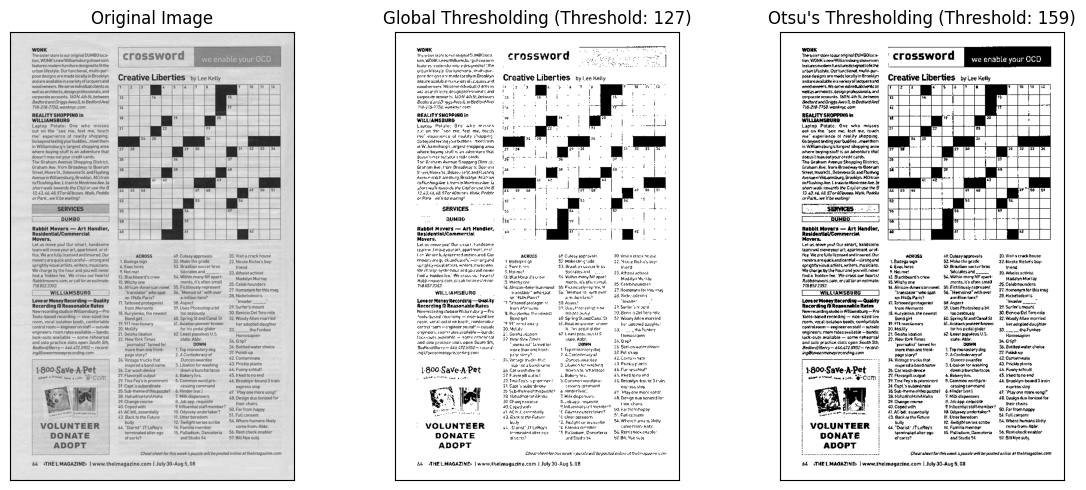

In [46]:
img_crossword_path = '/content/drive/MyDrive/PCVK/Images/crossword.jpg'
img_crossword = cv2.imread(img_crossword_path, cv2.IMREAD_GRAYSCALE)

threshold_value = 127
ret_global, thresh_global = cv2.threshold(img_crossword, threshold_value, 255, cv2.THRESH_BINARY)

ret_otsu, thresh_otsu = cv2.threshold(img_crossword, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_crossword, cmap='gray')
plt.title('Original Image')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(thresh_global, cmap='gray')
plt.title(f'Global Thresholding (Threshold: {threshold_value})')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(thresh_otsu, cmap='gray')
plt.title(f"Otsu's Thresholding (Threshold: {int(ret_otsu)})")
plt.xticks([]), plt.yticks([])


plt.tight_layout()
plt.show()

Global Thresholding
* How it works: Sets a fixed threshold value ($\mathbf{127}$) for the entire image.
* All pixels with values above 127 are set to white ($\mathbf{255}$).
* All pixels with values below or equal to 127 are set to black ($\mathbf{0}$).

Otsu's Thresholding
* How it works: This algorithm automatically determines the optimal threshold value (ret_otsu) by analyzing the image histogram.
* The goal is to find a threshold value that minimizes the variance (variability) in each class (foreground and background), or in other words, separates the two peaks of the histogram (dark and light) as well as possible.

Comparison of Results:
Generally, for document images such as crossword puzzles that have dark text on a light background, Otsu's Thresholding will provide cleaner and more accurate binarization results because it adjusts the threshold based on the image content, overcoming lighting issues that may not be ideal.